# Phân tích Thị trường Chứng khoán Đa cổ phiếu và Dự báo Xu hướng Giá sử dụng PySpark

## Tóm tắt Bài toán
Dự báo **xu hướng giá chứng khoán** (tăng/giảm) cho ngày tiếp theo dựa trên dữ liệu lịch sử từ **2013 đến 2026** sử dụng Machine Learning và PySpark.

**Mục tiêu chính:**
- Phân tích dữ liệu nhiều cổ phiếu (multi-stock)
- Xây dựng đặc trưng (features) hiệu quả bằng Window Functions
- Huấn luyện và so sánh 2 mô hình: Logistic Regression & Random Forest
- Đánh giá hiệu suất theo từng cổ phiếu
- Backtest chiến lược giao dịch dựa trên dự báo
- Tính lợi nhuận giả lập so với Buy & Hold strategy


## PHẦN 1: KHỞI TẠO PYSPARK VÀ IMPORT THƯ VIỆN

Trong phần này, chúng tôi sẽ:
- Import các thư viện cần thiết (PySpark, pandas, matplotlib, scikit-learn)
- Khởi tạo SparkSession cấu hình cho môi trường local
- Thiết lập cấu hình memory phù hợp

In [1]:
# Import thư viện PySpark
from pyspark.sql import SparkSession
from pyspark.sql.types import StringType, DoubleType, LongType
from pyspark.sql.functions import (
    col, to_timestamp, lag, lead, avg, when, count, sum as spark_sum,
    min as spark_min, max as spark_max, lit, greatest,
    abs as spark_abs
)
from pyspark.sql.window import Window
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pathlib import Path
# Import thư viện khác
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Cấu hình matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Đã import tất cả thư viện thành công!")

✓ Đã import tất cả thư viện thành công!


In [2]:
# Khởi tạo SparkSession cho local execution
spark = SparkSession.builder \
    .appName("StockAnalysisPySpark") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Cấu hình Spark
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
spark.sparkContext.setLogLevel("ERROR")

print("✓ SparkSession đã khởi tạo thành công!")
print(f"  - Spark Version: {spark.version}")
print(f"  - Python Version: {pd.__version__}")
print(f"  - NumPy Version: {np.__version__}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/21 04:48:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✓ SparkSession đã khởi tạo thành công!
  - Spark Version: 4.1.1
  - Python Version: 3.0.2
  - NumPy Version: 2.4.4


## PHẦN 2: NẠP VÀ KHÁM PHÁ DỮ LIỆU

Công việc trong phần này:
- Đọc tất cả file CSV từ thư mục `/home/admin/Documents/VSC/data/csv`
- Thêm cột `ticker` từ tên file
- Hiển thị schema, kiểu dữ liệu, và dòng dữ liệu mẫu
- Hiển thị thống kê cơ bản của các cột giá (open, high, low, close, volume)
- Liệt kê các cổ phiếu duy nhất (unique tickers)

In [3]:
# Đường dẫn thư mục dữ liệu (tự động theo thư mục hiện tại)
data_dir = str(Path("csv").resolve())
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))

print(f"📂 Tìm thấy {len(csv_files)} file CSV")
print(f"📍 Thư mục: {data_dir}\n")

# Đọc từng file và thêm cột ticker
dataframes = []
for csv_file in csv_files:
    ticker = os.path.basename(csv_file).replace('.csv', '')
    df_temp = spark.read.csv(csv_file, header=True, inferSchema=True)
    df_temp = df_temp.withColumn("ticker", lit(ticker))
    dataframes.append(df_temp)
    print(f"✓ Loaded: {ticker:6s} - {df_temp.count():,d} rows")

# Union tất cả dataframes
df_raw = dataframes[0]
for df_temp in dataframes[1:]:
    df_raw = df_raw.union(df_temp)

print(f"\n✓ Tổng dữ liệu: {df_raw.count():,d} rows từ {len(dataframes)} cổ phiếu")

📂 Tìm thấy 36 file CSV
📍 Thư mục: /home/admin/Documents/VSC/data/csv



✓ Loaded: SSI    - 2,573 rows
✓ Loaded: NLG    - 3,182 rows
✓ Loaded: NVDA   - 3,315 rows
✓ Loaded: MBB    - 3,182 rows
✓ Loaded: F      - 3,315 rows
✓ Loaded: JPM    - 3,330 rows
✓ Loaded: SAB    - 2,311 rows
✓ Loaded: AMD    - 3,330 rows
✓ Loaded: VPB    - 2,150 rows
✓ Loaded: AAPL   - 3,315 rows
✓ Loaded: VCB    - 3,182 rows
✓ Loaded: MSFT   - 3,315 rows
✓ Loaded: TSLA   - 3,315 rows
✓ Loaded: ACB    - 3,182 rows
✓ Loaded: META   - 3,315 rows
✓ Loaded: LCID   - 1,373 rows
✓ Loaded: VNINDEX - 3,301 rows
✓ Loaded: AMZN   - 3,315 rows
✓ Loaded: VNM    - 3,182 rows
✓ Loaded: TCB    - 1,941 rows
✓ Loaded: NFLX   - 3,330 rows
✓ Loaded: PNJ    - 2,481 rows
✓ Loaded: KDH    - 3,182 rows
✓ Loaded: MSN    - 3,182 rows
✓ Loaded: GAS    - 2,581 rows
✓ Loaded: FPT    - 3,182 rows
✓ Loaded: VIC    - 3,182 rows
✓ Loaded: RIVN   - 1,084 rows
✓ Loaded: GOOGL  - 3,315 rows
✓ Loaded: GM     - 3,315 rows
✓ Loaded: NKG    - 3,182 rows
✓ Loaded: HSG    - 3,182 rows
✓ Loaded: VHM    - 3,182 rows
✓ Loaded:

In [4]:
# Hiển thị schema và thông tin cơ bản
print("=" * 80)
print("SCHEMA CỦA DỮ LIỆU")
print("=" * 80)
df_raw.printSchema()

print("\n" + "=" * 80)
print("10 DÒNG DỮ LIỆU MẪU ĐẦU TIÊN")
print("=" * 80)
df_raw.show(10, truncate=False)

print("\n" + "=" * 80)
print("THỐNG KÊ CỌC BẢN")
print("=" * 80)
df_raw.describe(['open', 'high', 'low', 'close', 'volume']).show()

print("\n" + "=" * 80)
print("DANH SÁCH CỔ PHIẾU")
print("=" * 80)
tickers = df_raw.select("ticker").distinct().collect()
ticker_list = sorted([row.ticker for row in tickers])
print(f"Tổng {len(ticker_list)} cổ phiếu: {', '.join(ticker_list)}")

SCHEMA CỦA DỮ LIỆU
root
 |-- time: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: long (nullable = true)
 |-- ticker: string (nullable = false)


10 DÒNG DỮ LIỆU MẪU ĐẦU TIÊN
+----------+----+----+----+-----+--------+------+
|time      |open|high|low |close|volume  |ticker|
+----------+----+----+----+-----+--------+------+
|2015-12-08|6.46|6.57|6.4 |6.51 |2111780 |SSI   |
|2015-12-09|6.51|6.54|6.37|6.37 |1465550 |SSI   |
|2015-12-10|6.4 |6.43|6.37|6.37 |1558860 |SSI   |
|2015-12-11|6.34|6.43|6.32|6.32 |1448270 |SSI   |
|2015-12-14|6.48|6.54|6.4 |6.46 |3494550 |SSI   |
|2015-12-15|6.48|6.57|6.46|6.51 |2678080 |SSI   |
|2015-12-16|6.54|6.57|6.46|6.46 |773930  |SSI   |
|2015-12-17|6.51|6.51|6.43|6.43 |627550  |SSI   |
|2015-12-18|6.43|6.51|6.4 |6.51 |18905770|SSI   |
|2015-12-21|6.48|6.48|6.34|6.37 |2024770 |SSI   |
+----------+----+----+----+-----+--------+

+-------+------------------+------------------+-------------------+------------------+-------------------+
|summary|              open|              high|                low|             close|             volume|
+-------+------------------+------------------+-------------------+------------------+-------------------+
|  count|            107190|            107190|             107190|            107190|             107190|
|   mean| 52.52227771567419| 53.23331905324048|  51.78910305444775| 52.51596544591225|4.831385227862674E7|
| stddev|  78.2005294192981| 79.30510180813205|  77.05899922251629| 78.20586987411531|1.275179827358317E8|
|    min|0.2763485908508301|0.2800393976815044|0.27473387317438436|0.2758871251843646|                  0|
|    max| 788.1489868164062| 794.3843356438543|  778.9904964215748| 789.2963900548351|         3692928000|
+-------+------------------+------------------+-------------------+------------------+-------------------+


DANH SÁCH CỔ PHIẾU


Tổng 36 cổ phiếu: AAPL, ACB, AMD, AMZN, BID, CTG, F, FPT, GAS, GM, GOOGL, HPG, HSG, JPM, KDH, LCID, MBB, META, MSFT, MSN, NFLX, NKG, NLG, NVDA, PNJ, RIVN, SAB, SSI, TCB, TSLA, VCB, VHM, VIC, VNINDEX, VNM, VPB


## PHẦN 3: TIỀN XỬ LÝ DỮ LIỆU (PYSPARK)

Công việc chính:
- **Convert kiểu dữ liệu**: Chuyển cột `time` → `timestamp`, các cột giá/khối lượng → `double`/`long`
- **Loại bỏ bản ghi trùng** và dòng lỗi (giá <= 0)
- **Xử lý missing values**: Drop hoặc fill tùy theo tính chất dữ liệu
- **Sort dữ liệu**: Theo ticker và date để chuẩn bị cho window functions
- **Kiểm tra chất lượng**: Xác minh dữ liệu sau xử lý

In [5]:
# Step 1: Convert kiểu dữ liệu
print("Step 1: Convert kiểu dữ liệu...")
df_processed = df_raw \
    .withColumn("time", to_timestamp(col("time"), "yyyy-MM-dd")) \
    .withColumn("open", col("open").cast(DoubleType())) \
    .withColumn("high", col("high").cast(DoubleType())) \
    .withColumn("low", col("low").cast(DoubleType())) \
    .withColumn("close", col("close").cast(DoubleType())) \
    .withColumn("volume", col("volume").cast(LongType())) \
    .withColumn("ticker", col("ticker").cast(StringType()))

# Step 2: Loại bỏ null values
print("Step 2: Loại bỏ null values...")
null_count_before = df_processed.count()
df_processed = df_processed.dropna()
null_count_after = df_processed.count()
print(f"  - Loại bỏ {null_count_before - null_count_after:,d} dòng null")

# Step 3: Loại bỏ dòng lỗi (giá <= 0)
print("Step 3: Loại bỏ dòng lỗi (giá <= 0)...")
invalid_count = df_processed.filter((col("close") <= 0) | (col("volume") <= 0)).count()
df_processed = df_processed.filter((col("close") > 0) & (col("volume") > 0))
print(f"  - Loại bỏ {invalid_count:,d} dòng lỗi")

# Step 4: Loại bỏ bản ghi trùng
print("Step 4: Loại bỏ bản ghi trùng...")
df_processed = df_processed.dropDuplicates(['time', 'ticker'])

# Step 5: Sort theo ticker và date
print("Step 5: Sort theo ticker và date...")
df_processed = df_processed.sort(['ticker', 'time'])

print(f"\n✓ Dữ liệu sau xử lý: {df_processed.count():,d} rows")
print("\n10 dòng đầu sau xử lý:")
df_processed.show(10)

Step 1: Convert kiểu dữ liệu...
Step 2: Loại bỏ null values...


  - Loại bỏ 0 dòng null
Step 3: Loại bỏ dòng lỗi (giá <= 0)...


  - Loại bỏ 1,189 dòng lỗi
Step 4: Loại bỏ bản ghi trùng...
Step 5: Sort theo ticker và date...



✓ Dữ liệu sau xử lý: 106,001 rows

10 dòng đầu sau xử lý:


+-------------------+------------------+------------------+------------------+------------------+---------+------+
|               time|              open|              high|               low|             close|   volume|ticker|
+-------------------+------------------+------------------+------------------+------------------+---------+------+
|2013-01-02 00:00:00|16.596681594848633|16.777149815122606|16.372987598557668|16.741479468863204|560518000|  AAPL|
|2013-01-03 00:00:00| 16.38719367980957|16.616027941477572|   16.353941718276|16.561917828610618|352965200|  AAPL|
|2013-01-04 00:00:00|15.930726051330566|16.282290654722868|15.895357619331602|16.232110037056998|594333600|  AAPL|
|2013-01-07 00:00:00|15.837024688720703|16.000260712963588|15.574031163785353|15.779588894408562|484156400|  AAPL|
|2013-01-08 00:00:00|15.879646301269531| 16.07855428055573|15.756917391675056|15.997540058942361|458707200|  AAPL|
|2013-01-09 00:00:00|15.631468772888184|15.870580387667426|15.597913298188894|15

## PHẦN 4: PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA)

Mục đích:
- Chuyển Spark DataFrame sang pandas để vẽ biểu đồ
- Phân tích xu hướng giá theo thời gian cho các cổ phiếu đã chọn
- So sánh biến động giá giữa các cổ phiếu
- Phân tích mối quan hệ volume và giá
- Hiểu rõ đặc điểm dữ liệu trước khi xây dựng model

Chuyển dữ liệu Spark sang Pandas...


✓ Chuyển xong: 106,001 rows
Chọn 5 cổ phiếu đại diện: ['AAPL', 'ACB', 'AMD', 'AMZN', 'BID']


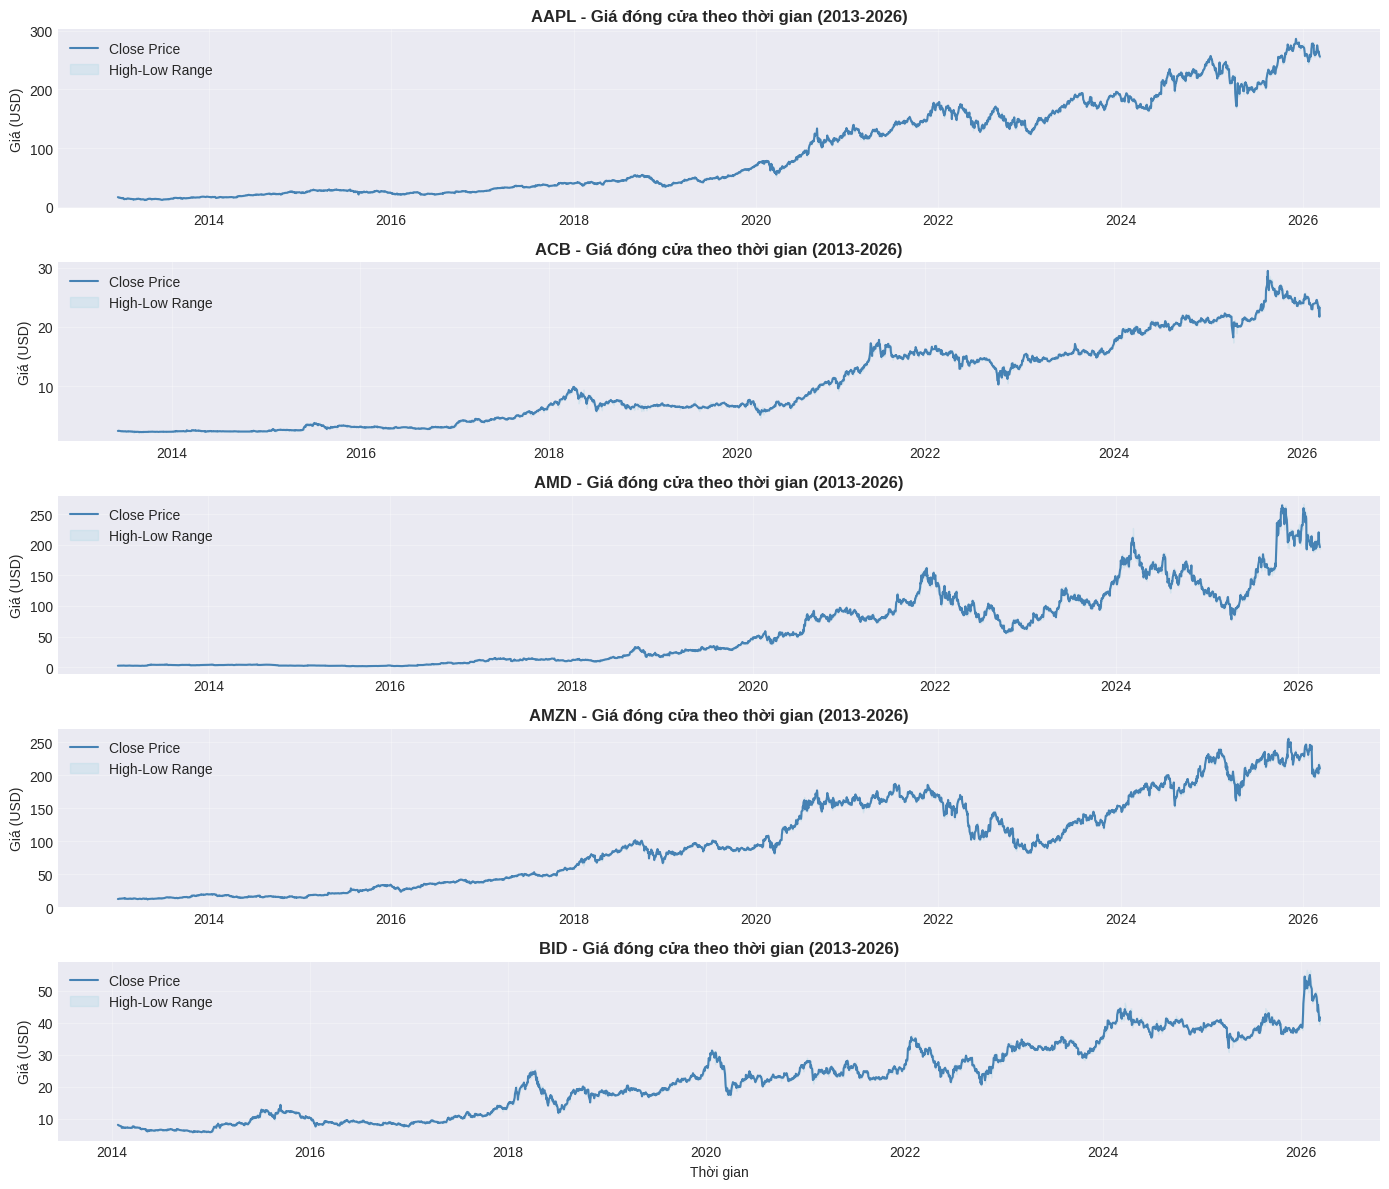

✓ Biểu đồ vẽ xong!


In [6]:
# Chuyển dữ liệu Spark sang Pandas để vẽ biểu đồ
print("Chuyển dữ liệu Spark sang Pandas...")
df_pandas = df_processed.toPandas()
df_pandas['time'] = pd.to_datetime(df_pandas['time'])

print(f"✓ Chuyển xong: {len(df_pandas):,d} rows")

# Chọn một vài cổ phiếu đại diện để vẽ biểu đồ
selected_tickers = df_pandas['ticker'].unique()[:5]
print(f"Chọn {len(selected_tickers)} cổ phiếu đại diện: {list(selected_tickers)}")

# Vẽ biểu đồ giá theo thời gian
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 12))
if len(selected_tickers) == 1:
    axes = [axes]

for idx, ticker in enumerate(selected_tickers):
    data = df_pandas[df_pandas['ticker'] == ticker].sort_values('time')
    axes[idx].plot(data['time'], data['close'], linewidth=1.5, color='steelblue', label='Close Price')
    axes[idx].fill_between(data['time'], data['low'], data['high'], alpha=0.3, color='lightblue', label='High-Low Range')
    axes[idx].set_title(f'{ticker} - Giá đóng cửa theo thời gian (2013-2026)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Giá (USD)', fontsize=10)
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)

plt.xlabel('Thời gian', fontsize=10)
plt.tight_layout()
plt.show()

print("✓ Biểu đồ vẽ xong!")

## PHẦN 5: FEATURE ENGINEERING

Sử dụng **PySpark Window Functions** (phân chia theo ticker, sắp xếp theo time) để tạo các đặc trưng dự báo.

### Vấn đề và cách xử lý

| Vấn đề | Giải pháp |
|--------|-----------|
| **Nhiễu từ các phiên biến động nhỏ** – các ngày tăng/giảm < 1% không mang tín hiệu rõ ràng | Dùng **label có ngưỡng**: chỉ coi là tăng/giảm khi `\|future_return\| > 1.0%` |
| **OHLCV thô không đủ thông tin thị trường** | Bổ sung 34 features kỹ thuật (RSI, MACD, BB, ATR, ADX, CCI, ...) |

### Nhóm đặc trưng (34 features tổng)

1. **Return & Lag**: `daily_return`, `lag1–3_close`, `lag1_volume`, `prev_high/low`, `lag5/10_return`
2. **Moving Average**: MA5, MA10, MA20, MA50, `price_vs_ma`
3. **Momentum**: RSI(7), RSI(14), Stochastic %K, Williams %R, CCI(14), Momentum 5/10
4. **Trend**: MACD, MACD Signal (SMA proxy trong Spark – EMA thực ở pipeline DL), ADX(14)
5. **Volatility**: ATR(14), ATR ratio, Bollinger upper/lower/bandwidth/%B, Volatility 5/20d
6. **Volume**: Volume change, Volume MA ratio, OBV signal
7. **Range**: High-low range, Close-open return

Cách này giúp giảm nhiễu cho bài toán tăng/giảm và cung cấp đủ ngữ cảnh thị trường để model tổng quát tốt hơn.

In [7]:
# Định nghĩa Window Function: Phân chia theo ticker, sắp xếp theo time
windowSpec = Window.partitionBy('ticker').orderBy('time')

print("Bắt đầu Feature Engineering sử dụng Window Functions...")

# Feature 1: Lag(Close)
df_features = df_processed \
    .withColumn('lag1_close', lag('close', 1).over(windowSpec)) \
    .withColumn('lag2_close', lag('close', 2).over(windowSpec)) \
    .withColumn('lag3_close', lag('close', 3).over(windowSpec)) \
    .withColumn('lag1_high',  lag('high',  1).over(windowSpec)) \
    .withColumn('lag1_low',   lag('low',   1).over(windowSpec))

# Feature 2: Lead(Close) – dùng để tạo label
df_features = df_features \
    .withColumn('next_close', lead('close', 1).over(windowSpec))

# Feature 3: Future Return
df_features = df_features \
    .withColumn('future_return', (col('next_close') - col('close')) / col('close'))

# Feature 4: Daily Return
df_features = df_features \
    .withColumn('daily_return', (col('close') - col('lag1_close')) / col('lag1_close'))

# Feature 5: Lag Return
df_features = df_features \
    .withColumn('lag1_return',  lag('daily_return',  1).over(windowSpec)) \
    .withColumn('lag5_return',  lag('daily_return',  5).over(windowSpec)) \
    .withColumn('lag10_return', lag('daily_return', 10).over(windowSpec))

# Feature 6-7: MA5 / MA10
df_features = df_features \
    .withColumn('ma5',  avg('close').over(windowSpec.rowsBetween(-4,  0))) \
    .withColumn('ma10', avg('close').over(windowSpec.rowsBetween(-9,  0)))

# ── CẢI TIẾN 2: Thêm MA20 / MA50 ──
df_features = df_features \
    .withColumn('ma20', avg('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('ma50', avg('close').over(windowSpec.rowsBetween(-49, 0)))

# ── CẢI TIẾN 2b: Price vs MA (momentum signal) ──
df_features = df_features \
    .withColumn('price_vs_ma5',  (col('close') - col('ma5'))  / col('ma5'))  \
    .withColumn('price_vs_ma20', (col('close') - col('ma20')) / col('ma20'))

# Feature 8: Rolling volatility 5-day
from pyspark.sql.functions import stddev_pop
df_features = df_features \
    .withColumn('rolling_volatility_5', stddev_pop('daily_return').over(windowSpec.rowsBetween(-4, 0)))

# Feature 9: RSI(14)
rsi_window = windowSpec.rowsBetween(-14, 0)
df_features = df_features \
    .withColumn('price_change', col('close') - col('lag1_close')) \
    .withColumn('gain', when(col('price_change') > 0, col('price_change')).otherwise(0.0)) \
    .withColumn('loss', when(col('price_change') < 0, -col('price_change')).otherwise(0.0)) \
    .withColumn('avg_gain_14', avg('gain').over(rsi_window)) \
    .withColumn('avg_loss_14', avg('loss').over(rsi_window)) \
    .withColumn('rs_14', when(col('avg_loss_14') == 0, None).otherwise(col('avg_gain_14') / col('avg_loss_14'))) \
    .withColumn('rsi_14', when(col('avg_loss_14') == 0, 100.0).otherwise(100 - (100 / (1 + col('rs_14')))))

# Feature 10: MACD (SMA proxy trong PySpark – PySpark không hỗ trợ ewm() nội sinh;
#             EMA thực được tính lại trong pipeline học sâu – Phần 11G)
df_features = df_features \
    .withColumn('ema12_proxy', avg('close').over(windowSpec.rowsBetween(-11, 0))) \
    .withColumn('ema26_proxy', avg('close').over(windowSpec.rowsBetween(-25, 0))) \
    .withColumn('macd', col('ema12_proxy') - col('ema26_proxy')) \
    .withColumn('macd_signal', avg('macd').over(windowSpec.rowsBetween(-8, 0)))

# Feature 11: Bollinger Bands (20-day)
df_features = df_features \
    .withColumn('bb_mid', avg('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('bb_std', stddev_pop('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('bb_upper', col('bb_mid') + (2 * col('bb_std'))) \
    .withColumn('bb_lower', col('bb_mid') - (2 * col('bb_std'))) \
    .withColumn('bb_bandwidth', when(col('bb_mid') != 0, (col('bb_upper') - col('bb_lower')) / col('bb_mid')).otherwise(None))

# Feature 12: Volume-based
df_features = df_features \
    .withColumn('lag1_volume', lag('volume', 1).over(windowSpec)) \
    .withColumn('volume_change', when(col('lag1_volume').isNull() | (col('lag1_volume') == 0), None)
                .otherwise((col('volume') - col('lag1_volume')) / col('lag1_volume'))) \
    .withColumn('high_low_range', when(col('close') != 0, (col('high') - col('low')) / col('close')).otherwise(None)) \
    .withColumn('close_open_return', when(col('open') != 0, (col('close') - col('open')) / col('open')).otherwise(None))

# ── CẢI TIẾN 3: Stochastic %K(14) ──
stoch_w = windowSpec.rowsBetween(-13, 0)
df_features = df_features \
    .withColumn('low14',  spark_min('low').over(stoch_w)) \
    .withColumn('high14', spark_max('high').over(stoch_w)) \
    .withColumn('stoch_k',
        when(col('high14') == col('low14'), 50.0)
        .otherwise((col('close') - col('low14')) / (col('high14') - col('low14')) * 100))

# ── Williams %R(14) – Stochastic đảo chiều ──
df_features = df_features \
    .withColumn('williams_r',
        when(col('high14') == col('low14'), -50.0)
        .otherwise((col('high14') - col('close')) / (col('high14') - col('low14')) * (-100)))

# ── CCI(14) – Commodity Channel Index (xấp xỉ bằng stddev thay vì MAD) ──
df_features = df_features \
    .withColumn('tp', (col('high') + col('low') + col('close')) / 3.0)
cci_w = windowSpec.rowsBetween(-13, 0)
df_features = df_features \
    .withColumn('tp_ma14',   avg('tp').over(cci_w)) \
    .withColumn('tp_std14',  stddev_pop('tp').over(cci_w)) \
    .withColumn('cci14',
        when(col('tp_std14') == 0, 0.0)
        .otherwise((col('tp') - col('tp_ma14')) / (0.015 * col('tp_std14'))))

# ── ADX(14) – Average Directional Index (đo độ mạnh xu hướng) ──
df_features = df_features \
    .withColumn('plus_dm',
        when((col('high') - col('lag1_high')) > (col('lag1_low') - col('low')),
             greatest(col('high') - col('lag1_high'), lit(0.0)))
        .otherwise(lit(0.0))) \
    .withColumn('minus_dm',
        when((col('lag1_low') - col('low')) > (col('high') - col('lag1_high')),
             greatest(col('lag1_low') - col('low'), lit(0.0)))
        .otherwise(lit(0.0))) \
    .withColumn('true_range', greatest(
        col('high') - col('low'),
        spark_abs(col('high') - col('lag1_close')),
        spark_abs(col('low')  - col('lag1_close'))))
adx_w = windowSpec.rowsBetween(-13, 0)
df_features = df_features \
    .withColumn('smooth_tr',   avg('true_range').over(adx_w)) \
    .withColumn('plus_di14',   when(col('smooth_tr') > 0, 100 * avg('plus_dm').over(adx_w)  / col('smooth_tr')).otherwise(0.0)) \
    .withColumn('minus_di14',  when(col('smooth_tr') > 0, 100 * avg('minus_dm').over(adx_w) / col('smooth_tr')).otherwise(0.0)) \
    .withColumn('adx14',
        when((col('plus_di14') + col('minus_di14')) == 0, 0.0)
        .otherwise(spark_abs(col('plus_di14') - col('minus_di14')) / (col('plus_di14') + col('minus_di14')) * 100))

# ── CẢI TIẾN 4: ATR(14) – Average True Range ──
df_features = df_features \
    .withColumn('atr14', avg(col('high') - col('low')).over(windowSpec.rowsBetween(-13, 0)))

# ── CẢI TIẾN 5: OBV direction signal (proxy – trung bình chiều giá 5 ngày, xấp xỉ tín hiệu OBV) ──
df_features = df_features \
    .withColumn('price_dir',
        when(col('close') > col('lag1_close'), 1.0)
        .when(col('close') < col('lag1_close'), -1.0)
        .otherwise(0.0)) \
    .withColumn('obv_signal', avg('price_dir').over(windowSpec.rowsBetween(-4, 0)))


# ── CẢI TIẾN 6: RSI(7) và RSI(21) – đa khung thời gian ──
# Tái dùng cột gain/loss đã tính từ RSI(14)
df_features = df_features \
    .withColumn('avg_gain_7',  avg('gain').over(windowSpec.rowsBetween(-7,  0))) \
    .withColumn('avg_loss_7',  avg('loss').over(windowSpec.rowsBetween(-7,  0))) \
    .withColumn('rsi_7',
        when(col('avg_loss_7') == 0, 100.0)
        .otherwise(100 - (100 / (1 + col('avg_gain_7') / col('avg_loss_7'))))) \
    .withColumn('avg_gain_21', avg('gain').over(windowSpec.rowsBetween(-21, 0))) \
    .withColumn('avg_loss_21', avg('loss').over(windowSpec.rowsBetween(-21, 0))) \
    .withColumn('rsi_21',
        when(col('avg_loss_21') == 0, 100.0)
        .otherwise(100 - (100 / (1 + col('avg_gain_21') / col('avg_loss_21')))))

# ── CẢI TIẾN 7: Volatility đa khung thời gian (10-day, 20-day) ──
df_features = df_features \
    .withColumn('rolling_volatility_10', stddev_pop('daily_return').over(windowSpec.rowsBetween(-9,  0))) \
    .withColumn('rolling_volatility_20', stddev_pop('daily_return').over(windowSpec.rowsBetween(-19, 0)))

# ── CẢI TIẾN 8: Volume MA Ratio – volume so với trung bình 20 phiên ──
df_features = df_features \
    .withColumn('avg_volume_20', avg('volume').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('volume_ma_ratio',
        when(col('avg_volume_20') == 0, None)
        .otherwise(col('volume') / col('avg_volume_20')))

# ── CẢI TIẾN 9: Momentum 5-day và 10-day ──
df_features = df_features \
    .withColumn('lag5_close',  lag('close', 5).over(windowSpec)) \
    .withColumn('lag10_close', lag('close', 10).over(windowSpec)) \
    .withColumn('momentum_5',
        when(col('lag5_close')  != 0, (col('close') - col('lag5_close'))  / col('lag5_close')).otherwise(None)) \
    .withColumn('momentum_10',
        when(col('lag10_close') != 0, (col('close') - col('lag10_close')) / col('lag10_close')).otherwise(None))

# ── CẢI TIẾN 10: Price vs MA50, MACD Histogram, Bollinger %B, ATR Ratio ──
df_features = df_features \
    .withColumn('price_vs_ma50',
        when(col('ma50') != 0, (col('close') - col('ma50')) / col('ma50')).otherwise(None)) \
    .withColumn('macd_hist', col('macd') - col('macd_signal')) \
    .withColumn('bb_pct_b',
        when((col('bb_upper') - col('bb_lower')) != 0,
             (col('close') - col('bb_lower')) / (col('bb_upper') - col('bb_lower'))).otherwise(None)) \
    .withColumn('atr_ratio',
        when(col('close') != 0, col('atr14') / col('close')).otherwise(None))

# ── CẢI TIẾN 11: Lag Returns 2 và 3 ──
df_features = df_features \
    .withColumn('lag2_return', lag('daily_return', 2).over(windowSpec)) \
    .withColumn('lag3_return', lag('daily_return', 3).over(windowSpec))

# ── FEATURES ĐẶC THÙ THỊ TRƯỜNG VN ─────────────────────────────────────────
vol_w = windowSpec.rowsBetween(-9, 0)

# 1. limit_hit_rate: tần suất chạm biên độ ±7% (20 phiên)
df_features = df_features \
    .withColumn('near_limit',
        when(spark_abs(col('daily_return')) >= 0.068, 1.0).otherwise(0.0)) \
    .withColumn('limit_hit_rate',
        avg('near_limit').over(windowSpec.rowsBetween(-19, 0)))

# 2. zero_change_rate: tần suất giá không đổi (10 phiên)
df_features = df_features \
    .withColumn('no_change',
        when(col('daily_return') == 0.0, 1.0).otherwise(0.0)) \
    .withColumn('zero_change_rate',
        avg('no_change').over(windowSpec.rowsBetween(-9, 0)))

# 3. vol_consistency: std/mean khối lượng (10 phiên) – bất ổn thanh khoản
df_features = df_features \
    .withColumn('vol_std10',  stddev_pop('volume').over(vol_w)) \
    .withColumn('vol_mean10', avg('volume').over(vol_w)) \
    .withColumn('vol_consistency',
        when(col('vol_mean10') > 0, col('vol_std10') / col('vol_mean10')).otherwise(None))

# 4. intraday_pos: vị trí close trong dải high-low (0=đáy, 1=trần)
df_features = df_features \
    .withColumn('intraday_pos',
        when((col('high') - col('low')) > 0,
             (col('close') - col('low')) / (col('high') - col('low'))
        ).otherwise(0.5))

# 5. ato_gap: gap giá ATO mở cửa so với close hôm trước
df_features = df_features \
    .withColumn('ato_gap',
        when(col('lag1_close') != 0,
             (col('open') - col('lag1_close')) / col('lag1_close')
        ).otherwise(None))


# ── Cải tiến 1: 3-day forward return làm label (ít noise hơn next-day) ────
from pyspark.sql.functions import create_map, to_date
df_features = df_features     .withColumn('next_close_3d', lead('close', 3).over(windowSpec))     .withColumn('future_return_3d',
        when(col('close') != 0,
             (col('next_close_3d') - col('close')) / col('close')
        ).otherwise(None))

# ── Cải tiến 2: Sector encoding ─────────────────────────────────────────────
SECTOR_MAP = {
    'ACB': 0, 'BID': 0, 'CTG': 0, 'MBB': 0, 'TCB': 0, 'VCB': 0, 'VPB': 0,
    'SSI': 1,
    'HPG': 2, 'HSG': 2, 'NKG': 2,
    'KDH': 3, 'NLG': 3, 'VHM': 3, 'VIC': 3,
    'MSN': 4, 'SAB': 4, 'VNM': 4, 'PNJ': 4, 'GAS': 4,
    'FPT': 5,
    'AAPL': 6, 'MSFT': 6, 'GOOGL': 6, 'META': 6, 'NVDA': 6, 'NFLX': 6, 'AMD': 6,
    'TSLA': 7, 'F': 7, 'GM': 7,
    'JPM': 8,
    'AMZN': 9,
}
sector_expr = create_map(
    *[item for pair in [(lit(k), lit(float(v))) for k, v in SECTOR_MAP.items()] for item in pair]
)
df_features = df_features.withColumn('sector_idx', sector_expr[col('ticker')])

# ── Cải tiến 3: VN-Index context features ───────────────────────────────────
vnindex_path = str(Path("csv/VNINDEX.csv").resolve())
df_vni = spark.read.option("header", True).option("inferSchema", True).csv(vnindex_path)
df_vni = df_vni.withColumn('time', to_date(col('time')))                .withColumn('vni_close', col('close').cast('double'))

vni_win = Window.orderBy('time')
df_vni = df_vni     .withColumn('vni_ret1d',
        (col('vni_close') - lag('vni_close', 1).over(vni_win)) / lag('vni_close', 1).over(vni_win))     .withColumn('vni_ma5',   avg('vni_close').over(vni_win.rowsBetween(-4, 0)))     .withColumn('vni_ma20',  avg('vni_close').over(vni_win.rowsBetween(-19, 0)))     .withColumn('vni_mom5',  (col('vni_close') / lag('vni_close', 5).over(vni_win)) - 1)     .withColumn('vni_ma_ratio', col('vni_ma5') / col('vni_ma20') - 1)     .select('time', 'vni_ret1d', 'vni_mom5', 'vni_ma_ratio')

df_features = df_features     .withColumn('time_date', to_date(col('time')))     .join(df_vni.withColumnRenamed('time', 'vni_date'), col('time_date') == col('vni_date'), 'left')     .drop('vni_date', 'time_date')     .fillna(0.0, subset=['vni_ret1d', 'vni_mom5', 'vni_ma_ratio'])

print("\u2713 Feature Engineering xong!")
print(f"  3-day label, sector_idx, VN-Index features da duoc them")
print(f"\nDu lieu sau feature engineering: {df_features.count():,d} rows")
df_features.select('time', 'ticker', 'close', 'future_return', 'future_return_3d',
                   'sector_idx', 'vni_ret1d', 'vni_mom5').show(5)


Bắt đầu Feature Engineering sử dụng Window Functions...
✓ Feature Engineering xong!
  3-day label, sector_idx, VN-Index features da duoc them



Du lieu sau feature engineering: 106,001 rows


+-------------------+------+------------------+--------------------+--------------------+----------+--------------------+--------+
|               time|ticker|             close|       future_return|    future_return_3d|sector_idx|           vni_ret1d|vni_mom5|
+-------------------+------+------------------+--------------------+--------------------+----------+--------------------+--------+
|2013-01-02 00:00:00|  AAPL|16.741479468863204|-0.01072555389065...|-0.05745552991559817|       6.0|                 0.0|     0.0|
|2013-01-03 00:00:00|  AAPL|16.561917828610618|-0.01991362322688...|-0.03407683672317...|       6.0|                 0.0|     0.0|
|2013-01-04 00:00:00|  AAPL|16.232110037056998|-0.02787814656353091|-0.02694691078214048|       6.0|0.023809523809523832|     0.0|
|2013-01-07 00:00:00|  AAPL|15.779588894408562|0.013812220710707453|0.012547230230327392|       6.0|                 0.0|     0.0|
|2013-01-08 00:00:00|  AAPL|15.997540058942361|-0.01267915205165...|-0.015513698303

## PHẦN 6: LÀM SẠCH DỮ LIỆU SAU FEATURE ENGINEERING

Sau khi tạo features bằng lag() và window functions, sẽ có dòng null:
- Dòng đầu tiên mỗi ticker sẽ có null trong lag columns
- Dòng cuối cùng mỗi ticker sẽ có null trong `next_close` và `future_return`
- Các dòng có biến động nhỏ quanh 0 cũng được gán `label = null` để loại bỏ nhiễu

Bước này sẽ:
- **Drop tất cả null rows**
- **Xác minh dữ liệu đã sạch**
- **Kiểm tra phân phối label** (có cân bằng không?)

In [8]:
# Drop null values do lag/window functions (label chưa tồn tại – xử lý sau khi tách market)
print("Dropping null values (features only)...")
count_before = df_features.count()
df_features  = df_features.dropna(
    subset=[c for c in df_features.columns if c not in ('label', 'next_close')]
)
count_after  = df_features.count()
print(f"✓ Loại bỏ {count_before - count_after:,d} rows null ({(count_before-count_after)/count_before*100:.1f}%)")
print(f"  Dữ liệu sau drop null: {count_after:,d} rows")

# Winsorize: clip extreme outliers
print("\nWinsorizing extreme feature values...")
clip_map = {
    "daily_return":      (-0.15, 0.15),
    "lag1_return":       (-0.15, 0.15),
    "lag2_return":       (-0.15, 0.15),
    "lag3_return":       (-0.15, 0.15),
    "close_open_return": (-0.15, 0.15),
    "momentum_5":        (-0.35, 0.35),
    "momentum_10":       (-0.50, 0.50),
    "volume_change":     (-3.0,  5.0),
    "volume_ma_ratio":   (0.05,  8.0),
    "high_low_range":    (0.0,   0.20),
    "price_vs_ma5":      (-0.20, 0.20),
    "price_vs_ma20":     (-0.30, 0.30),
    "price_vs_ma50":     (-0.40, 0.40),
    "bb_pct_b":          (-0.50, 1.50),
    "atr_ratio":         (0.0,   0.10),
    "rsi_7":             (0.0,  100.0),
    "rsi_14":            (0.0,  100.0),
    "rsi_21":            (0.0,  100.0),
    "stoch_k":           (0.0,  100.0),
}
for cname, (lo, hi) in clip_map.items():
    if cname in df_features.columns:
        df_features = df_features.withColumn(
            cname,
            when(col(cname) < lo, lo).when(col(cname) > hi, hi).otherwise(col(cname))
        )
print(f"✓ Winsorized {len(clip_map)} features")
print(f"\n✓ df_features sẵn sàng: {df_features.count():,d} rows — label sẽ tạo riêng cho US/VN ở PHẦN 7")


Dropping null values (features only)...


✓ Loại bỏ 6,242 rows null (5.9%)
  Dữ liệu sau drop null: 99,759 rows

Winsorizing extreme feature values...
✓ Winsorized 19 features



✓ df_features sẵn sàng: 99,759 rows — label sẽ tạo riêng cho US/VN ở PHẦN 7


## PHẦN 7: TÁCH THỊ TRƯỜNG US vs VN + TẠO LABEL

Sau khi có đầy đủ features, chia `df_features` thành 2 nhánh:

| Thị trường | Ngưỡng label | Lý do |
|------------|-------------|-------|
| **US** | 1.5% | Biến động ngày lớn hơn |
| **VN** | 0.7% | Biên độ +-7%, ít biến động hơn |

Từ đây **tất cả bước tiếp theo chạy riêng** cho từng thị trường.


In [9]:
from pyspark.sql.functions import year, avg as spark_avg

US_TICKERS = ['AAPL','AMZN','F','GM','GOOGL','META','MSFT','NFLX','AMD','NVDA','TSLA']
VN_TICKERS = ['ACB','BID','CTG','FPT','GAS','HPG','HSG','KDH','MBB','MSN','NKG','NLG',
               'PNJ','SAB','SSI','TCB','VCB','VHM','VIC','VNM','VPB']

# Tat ca ma VN hop nhat thanh mot nhom
print('=' * 60)
print('DANH SACH MA VN')
print('=' * 60)
print(f'  Tong {len(VN_TICKERS)} ma VN: {VN_TICKERS}')

# Tao label voi nguong rieng cho tung nhom
# US: next-day label
def create_labels(df, threshold):
    return (
        df.withColumn('label',
            when(col('future_return') >  threshold, 1.0)
           .when(col('future_return') < -threshold, 0.0)
           .otherwise(None))
        .dropna(subset=['label', 'next_close'])
        .withColumn('year', year('time'))
    )

# VN: 3-day forward label (giam noise thi truong VN)
def create_labels_3d(df, threshold):
    return (
        df.withColumn('label',
            when(col('future_return_3d') >  threshold, 1.0)
           .when(col('future_return_3d') < -threshold, 0.0)
           .otherwise(None))
        .dropna(subset=['label', 'next_close_3d'])
        .withColumn('year', year('time'))
    )

df_us = create_labels(df_features.filter(col('ticker').isin(US_TICKERS)), threshold=0.015)
df_vn = create_labels_3d(df_features.filter(col('ticker').isin(VN_TICKERS)), threshold=0.008)

print('\n' + '=' * 60)
print('THONG KE 3 NHOM')
print('=' * 60)
for name, df_m in [('US', df_us), ('VN', df_vn)]:
    n = df_m.count()
    dist = {int(r['label']): r['count'] for r in df_m.groupBy('label').count().collect()}
    n0, n1 = dist.get(0, 0), dist.get(1, 0)
    tickers_m = sorted([r['ticker'] for r in df_m.select('ticker').distinct().collect()])
    print(f'  {name:<10}: {n:,d} rows | L0={n0:,d}({n0/n*100:.0f}%) L1={n1:,d}({n1/n*100:.0f}%)')
    print(f'             Tickers: {", ".join(tickers_m)}')


DANH SACH MA VN
  Tong 21 ma VN: ['ACB', 'BID', 'CTG', 'FPT', 'GAS', 'HPG', 'HSG', 'KDH', 'MBB', 'MSN', 'NKG', 'NLG', 'PNJ', 'SAB', 'SSI', 'TCB', 'VCB', 'VHM', 'VIC', 'VNM', 'VPB']

THONG KE 3 NHOM


  US        : 14,304 rows | L0=6,610(46%) L1=7,694(54%)
             Tickers: AAPL, AMD, AMZN, F, GM, GOOGL, META, MSFT, NFLX, NVDA, TSLA


  VN        : 44,562 rows | L0=21,121(47%) L1=23,441(53%)
             Tickers: ACB, BID, CTG, FPT, GAS, HPG, HSG, KDH, MBB, MSN, NKG, NLG, PNJ, SAB, SSI, TCB, VCB, VHM, VIC, VNM, VPB


## PHẦN 8: ĐỊNH NGHĨA PIPELINE FUNCTIONS

- **`run_spark_pipeline(df, market)`** — Train LR, RF, GBT, SVC + Ensemble (PySpark ML)
- **`run_xgb_pipeline(df, market)`** — Train XGBoost voi EMA MACD thuc (pandas/sklearn)

Goi moi ham 2 lan: mot lan cho US, mot lan cho VN.


In [10]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.feature import StandardScaler as SparkSS
from pyspark.ml.classification import (LogisticRegression, RandomForestClassifier,
                                        GBTClassifier, LinearSVC)
from pyspark.ml.evaluation import (MulticlassClassificationEvaluator,
                                    BinaryClassificationEvaluator)
from pyspark.sql.functions import log1p as spark_log1p

FEATURE_COLS = [
    # Returns & lags
    'daily_return', 'lag1_return', 'lag2_return', 'lag3_return',
    'lag5_return',  'lag10_return',
    # Price lags
    'lag1_close',   'lag2_close',   'lag3_close',
    # Trend
    'price_vs_ma5', 'price_vs_ma20','price_vs_ma50',
    'momentum_5',   'momentum_10',
    # Oscillators
    'rsi_7', 'rsi_14', 'macd_hist',
    'stoch_k', 'williams_r', 'cci14',
    # Volatility & trend strength
    'rolling_volatility_5', 'rolling_volatility_20',
    'bb_bandwidth', 'bb_pct_b', 'atr_ratio', 'adx14',
    # Volume
    'log_volume', 'log_lag1_volume', 'volume_change', 'volume_ma_ratio',
    # Price action
    'high_low_range', 'close_open_return', 'obv_signal',
    # VN-specific features
    'limit_hit_rate', 'zero_change_rate', 'vol_consistency',
    'intraday_pos',   'ato_gap',
    # Sector & market context
    'sector_idx',
    'vni_ret1d', 'vni_mom5', 'vni_ma_ratio',
    # Ticker encoding
    'ticker_idx',
]

def run_spark_pipeline(df_market, market_name):
    sep = '=' * 70
    print(f'\n{sep}\nSPARK ML — {market_name} STOCKS\n{sep}')

    df_tr = df_market.filter(col('year') <= 2021)
    df_ts = df_market.filter(col('year') >= 2022)
    n_tr, n_ts = df_tr.count(), df_ts.count()
    print(f'  Train: {n_tr:,d} | Test: {n_ts:,d}')

    ti_m = StringIndexer(inputCol='ticker', outputCol='ticker_idx', handleInvalid='keep').fit(df_tr)
    def prep(df):
        return (ti_m.transform(df)
                .withColumn('log_volume',      spark_log1p(col('volume').cast('double')))
                .withColumn('log_lag1_volume', spark_log1p(col('lag1_volume').cast('double'))))
    df_tr = prep(df_tr)
    df_ts = prep(df_ts)

    va   = VectorAssembler(inputCols=FEATURE_COLS, outputCol='raw_features', handleInvalid='skip')
    sc_m = SparkSS(inputCol='raw_features', outputCol='features', withMean=True, withStd=True).fit(va.transform(df_tr))
    df_tr_asm = sc_m.transform(va.transform(df_tr))
    df_ts_asm = sc_m.transform(va.transform(df_ts))

    lc  = {r['label']: r['count'] for r in df_tr.groupBy('label').count().collect()}
    tot = sum(lc.values())
    df_tr_asm = df_tr_asm.withColumn('weight',
        when(col('label') == 1.0, tot/(2.0*lc.get(1.0,1))).otherwise(tot/(2.0*lc.get(0.0,1))))

    models_cfg = {
        'LR':  LogisticRegression(featuresCol='features', labelCol='label', weightCol='weight',
                                   maxIter=200, regParam=0.001, elasticNetParam=0.0),
        'RF':  RandomForestClassifier(featuresCol='features', labelCol='label', weightCol='weight',
                                       numTrees=150, maxDepth=12, minInstancesPerNode=3,
                                       featureSubsetStrategy='sqrt', seed=42),
        'GBT': GBTClassifier(featuresCol='features', labelCol='label',
                              maxIter=200, maxDepth=5, stepSize=0.03, subsamplingRate=0.7,
                              featureSubsetStrategy='sqrt', minInstancesPerNode=5, seed=42),
        'SVC': LinearSVC(featuresCol='features', labelCol='label', maxIter=200, regParam=0.001),
    }
    print('  Training models:')
    trained, predictions = {}, {}
    for mname, mdl in models_cfg.items():
        print(f'    {mname}...', end=' ', flush=True)
        fitted = mdl.fit(df_tr_asm)
        predictions[mname] = fitted.transform(df_ts_asm)
        trained[mname] = fitted
        print('ok')

    acc_ev = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
    auc_ev = BinaryClassificationEvaluator(rawPredictionCol='rawPrediction', labelCol='label', metricName='areaUnderROC')
    metrics = {}
    print(f'\n  {"Model":<10} {"Accuracy":>10} {"AUC-ROC":>10}')
    print('  ' + '-' * 32)
    for mname, preds in predictions.items():
        acc = acc_ev.evaluate(preds)
        try:    auc = auc_ev.evaluate(preds)
        except: auc = float('nan')
        metrics[mname] = {'accuracy': acc, 'auc': auc}
        print(f'  {mname:<10} {acc:>10.4f} {auc:>10.4f}')

    total_acc = sum(m['accuracy'] for m in metrics.values())
    w = {k: v['accuracy']/total_acc for k, v in metrics.items()}
    ens_df = (
        predictions['LR'].select('time','ticker','label','next_close', col('prediction').alias('p_lr'))
        .join(predictions['RF'].select('time','ticker', col('prediction').alias('p_rf')),  ['time','ticker'])
        .join(predictions['GBT'].select('time','ticker',col('prediction').alias('p_gbt')), ['time','ticker'])
        .join(predictions['SVC'].select('time','ticker',col('prediction').alias('p_svc')), ['time','ticker'])
        .withColumn('vote',
            col('p_lr')*lit(w['LR']) + col('p_rf')*lit(w['RF']) +
            col('p_gbt')*lit(w['GBT']) + col('p_svc')*lit(w['SVC']))
        .withColumn('prediction', when(col('vote') >= 0.5, 1.0).otherwise(0.0))
    )
    ens_acc = acc_ev.evaluate(ens_df)
    metrics['Ensemble'] = {'accuracy': ens_acc, 'auc': float('nan')}
    print(f'  {"Ensemble":<10} {ens_acc:>10.4f}')

    ticker_acc = {}
    for mname, preds in {**predictions, 'Ensemble': ens_df}.items():
        ta = (preds
              .withColumn('correct', (col('prediction')==col('label')).cast('int'))
              .groupBy('ticker').agg((spark_sum('correct')/count('*')).alias('acc'))
              .toPandas().set_index('ticker')['acc'])
        ticker_acc[mname] = ta

    fi = sorted(zip(FEATURE_COLS, trained['RF'].featureImportances), key=lambda x: -x[1])
    print(f'\n  Top 5 features ({market_name}): ' + ', '.join(f[0] for f in fi[:5]))
    print(f'\nok {market_name} Spark pipeline xong!')
    return {'market': market_name, 'n_train': n_tr, 'n_test': n_ts,
            'metrics': metrics, 'predictions': predictions,
            'ensemble': ens_df, 'ticker_acc': ticker_acc, 'feature_importance': fi}

print('ok run_spark_pipeline() dinh nghia xong')


ok run_spark_pipeline() dinh nghia xong


In [11]:
def run_xgb_pipeline(df_spark, market_name):
    from xgboost import XGBClassifier as XGBCls
    from sklearn.preprocessing import StandardScaler as SS
    from sklearn.metrics import accuracy_score, roc_auc_score

    sep = '=' * 70
    print(f'\n{sep}\nXGBOOST — {market_name} STOCKS\n{sep}')

    XGB_BASE = [c for c in FEATURE_COLS if c not in
                ('ticker_idx','macd_hist','log_volume','log_lag1_volume')]
    needed = list(set(['time','ticker','close','volume','lag1_volume','label','year',
                        'next_close'] + XGB_BASE))
    avail  = [c for c in needed if c in df_spark.columns]

    df_pd = df_spark.select(*avail).toPandas()
    df_pd['time'] = pd.to_datetime(df_pd['time'])
    df_pd = df_pd.sort_values(['ticker','time']).reset_index(drop=True)
    print(f'  {len(df_pd):,d} rows | {df_pd["ticker"].nunique()} tickers')

    ema12 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=12, adjust=False).mean())
    ema26 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=26, adjust=False).mean())
    macd_r = ema12 - ema26
    df_pd['_macd_r'] = macd_r
    macd_sig = df_pd.groupby('ticker')['_macd_r'].transform(lambda s: s.ewm(span=9, adjust=False).mean())
    df_pd.drop(columns=['_macd_r'], inplace=True)
    cs = df_pd['close'].where(df_pd['close'] != 0, np.nan)
    df_pd['macd_real']      = (macd_r / cs).fillna(0)
    df_pd['macd_hist_real'] = ((macd_r - macd_sig) / cs).fillna(0)
    df_pd['log_volume']      = np.log1p(df_pd['volume'].clip(lower=0))
    df_pd['log_lag1_volume'] = np.log1p(df_pd['lag1_volume'].clip(lower=0))

    feat_xgb = [c for c in XGB_BASE if c in df_pd.columns]
    feat_xgb += ['log_volume','log_lag1_volume','macd_real','macd_hist_real']
    feat_xgb  = [c for c in feat_xgb if c in df_pd.columns]

    df_pd = df_pd.dropna(subset=feat_xgb + ['label'])
    df_tr = df_pd[df_pd['year'] <= 2021]
    df_ts = df_pd[df_pd['year'] >= 2022]
    print(f'  Train: {len(df_tr):,d} | Test: {len(df_ts):,d}')

    sc_xgb = SS()
    X_tr = sc_xgb.fit_transform(df_tr[feat_xgb].values.astype(np.float64))
    y_tr = df_tr['label'].values.astype(int)
    X_ts = sc_xgb.transform(df_ts[feat_xgb].values.astype(np.float64))
    y_ts = df_ts['label'].values.astype(int)

    counts = np.bincount(y_tr)
    n0 = int(counts[0]) if len(counts) > 0 else 1
    n1 = int(counts[1]) if len(counts) > 1 else 1

    mdl = XGBCls(n_estimators=400, max_depth=5, learning_rate=0.03,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                  scale_pos_weight=float(n0)/float(max(n1,1)),
                  random_state=42, n_jobs=-1, verbosity=0, eval_metric='logloss')
    mdl.fit(X_tr, y_tr, eval_set=[(X_ts, y_ts)], verbose=False)

    y_pred = mdl.predict(X_ts)
    y_prob = mdl.predict_proba(X_ts)[:,1]
    acc = accuracy_score(y_ts, y_pred)
    auc = roc_auc_score(y_ts, y_prob)

    df_ts_c = df_ts.copy()
    df_ts_c['pred'] = y_pred
    ticker_acc = df_ts_c.groupby('ticker').apply(
        lambda g: accuracy_score(g['label'].astype(int), g['pred']))

    fi_xgb = pd.Series(mdl.feature_importances_, index=feat_xgb).nlargest(5)
    print(f'  XGBoost: Accuracy={acc:.4f}  AUC-ROC={auc:.4f}')
    print(f'  Top 5: {", ".join(fi_xgb.index.tolist())}')
    print(f'\nok {market_name} XGBoost xong!')
    return {'accuracy': acc, 'auc': auc, 'model': mdl, 'scaler': sc_xgb, 'features': feat_xgb,
            'ticker_acc': ticker_acc, 'feature_importance': fi_xgb,
            'df_ts': df_ts_c, 'y_ts': y_ts, 'y_pred': y_pred}

print('ok run_xgb_pipeline() dinh nghia xong')


ok run_xgb_pipeline() dinh nghia xong


## PHẦN 9: CHẠY PIPELINE CHO US VÀ VN

Goi lan luot `run_spark_pipeline` + `run_xgb_pipeline` cho tung thi truong.
Moi pipeline doc lap hoan toan: scaler, StringIndexer, class weight deu fit rieng.


In [12]:
# US STOCKS
res_us     = run_spark_pipeline(df_us, 'US')
res_us_xgb = run_xgb_pipeline(df_us,  'US')



SPARK ML — US STOCKS


  Train: 9,046 | Test: 5,258


  Training models:
    LR... 

ok
    RF... 

ok
    GBT... 

...

  GBT            0.8397     0.9322


  SVC            0.8302     0.8926


  Ensemble       0.8412



  Top 5 features (US): close_open_return, intraday_pos, ato_gap, ticker_idx, daily_return

ok US Spark pipeline xong!

XGBOOST — US STOCKS


  14,304 rows | 11 tickers
  Train: 9,046 | Test: 5,258
  XGBoost: Accuracy=0.8429  AUC-ROC=0.9291
  Top 5: close_open_return, intraday_pos, sector_idx, ato_gap, zero_change_rate

ok US XGBoost xong!


In [13]:
# VN STOCKS
res_vn     = run_spark_pipeline(df_vn, 'VN')
res_vn_xgb = run_xgb_pipeline(df_vn,  'VN')


SPARK ML — VN STOCKS


  Train: 28,202 | Test: 16,360


  Training models:
    LR... 

ok
    RF... 

ok
    GBT... 

...

  GBT            0.5265     0.5319


  SVC            0.5154     0.5306


  Ensemble       0.5311



  Top 5 features (VN): vni_ma_ratio, vni_mom5, vni_ret1d, vol_consistency, price_vs_ma50

ok VN Spark pipeline xong!

XGBOOST — VN STOCKS


  44,562 rows | 21 tickers
  Train: 28,202 | Test: 16,360
  XGBoost: Accuracy=0.5109  AUC-ROC=0.5199
  Top 5: vni_mom5, vni_ret1d, vni_ma_ratio, intraday_pos, price_vs_ma50

ok VN XGBoost xong!


## PHẦN 10: SO SÁNH KẾT QUẢ US vs VN

Tong hop toan bo 6 model (LR, RF, GBT, SVC, Ensemble, XGBoost) cho hai thi truong US va VN.

SO SANH 6 MODEL: US vs VN
Market        US      VN  Diff(US-VN)
Model                                
RF        0.8452  0.5277       0.3175
XGBoost   0.8429  0.5109       0.3320
Ensemble  0.8412  0.5311       0.3101
GBT       0.8397  0.5265       0.3131
SVC       0.8302  0.5154       0.3148
LR        0.8218  0.5197       0.3021

ACCURACY THEO TUNG TICKER

US (Spark best: RF)
        Spark_best  XGBoost
ticker                     
AAPL        0.9503   0.9348
TSLA        0.9451   0.9421
F           0.9444   0.9533
NVDA        0.9369   0.9369
META        0.9357   0.9212
MSFT        0.9333   0.9212
AMZN        0.9249   0.9202
GM          0.9234   0.9189
GOOGL       0.9139   0.9211
NFLX        0.5097   0.5269
AMD         0.5008   0.4928

VN (Spark best: Ensemble)
        Spark_best  XGBoost
ticker                     
MBB         0.5685   0.5465
TCB         0.5620   0.5025
NKG         0.5586   0.5169
SAB         0.5551   0.5689
CTG         0.5541   0.5210
BID         0.5534   0.5244
SSI    

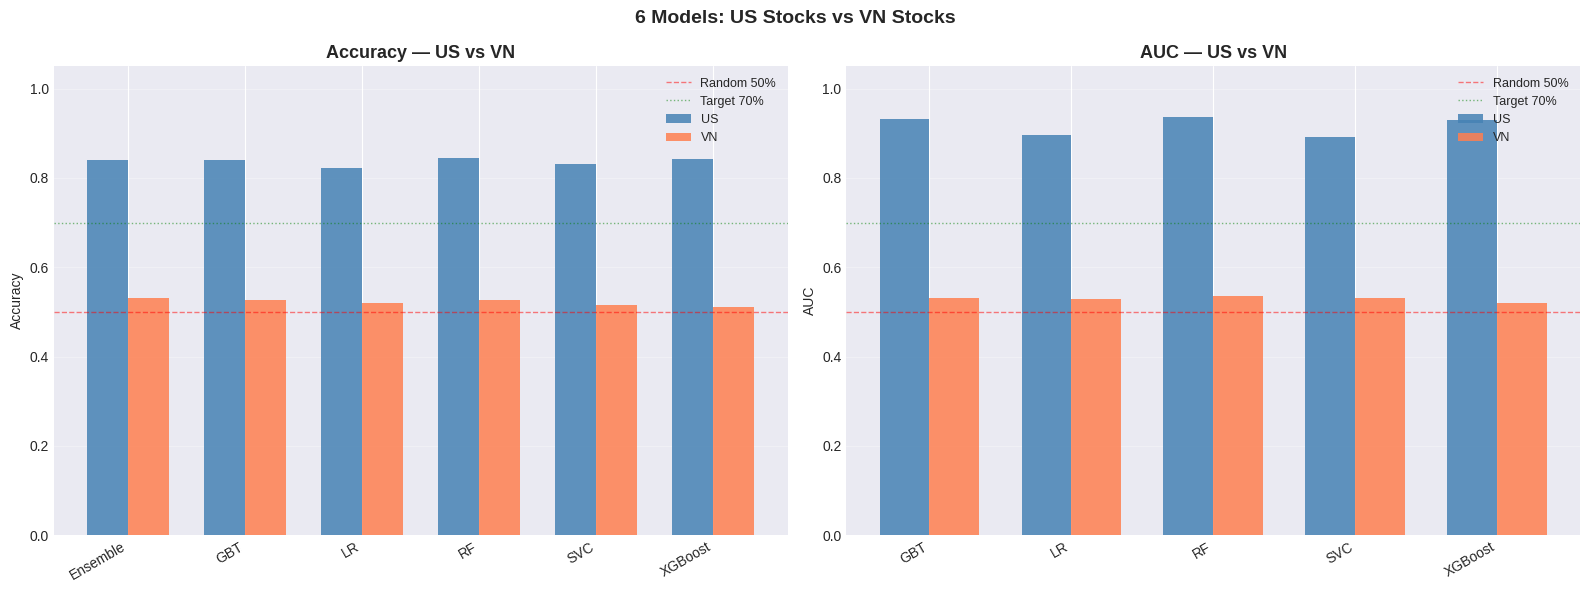

ok Bieu do so sanh xong!


In [14]:
rows = []
for res, res_xgb in [(res_us, res_us_xgb), (res_vn, res_vn_xgb)]:
    m = res['market']
    for mname, met in res['metrics'].items():
        rows.append({'Market': m, 'Model': mname,
                     'Accuracy': met['accuracy'], 'AUC': met['auc']})
    rows.append({'Market': m, 'Model': 'XGBoost',
                 'Accuracy': res_xgb['accuracy'], 'AUC': res_xgb['auc']})

compare_df = pd.DataFrame(rows)
print('=' * 70)
print('SO SANH 6 MODEL: US vs VN')
print('=' * 70)
pivot = compare_df.pivot_table(index='Model', columns='Market', values='Accuracy')
if 'US' in pivot.columns and 'VN' in pivot.columns:
    pivot['Diff(US-VN)'] = pivot['US'] - pivot['VN']
print(pivot.round(4).sort_values('US', ascending=False).to_string())

print('\n' + '=' * 70)
print('ACCURACY THEO TUNG TICKER')
print('=' * 70)
for res, res_xgb in [(res_us, res_us_xgb), (res_vn, res_vn_xgb)]:
    best_k = max(res['metrics'], key=lambda k: res['metrics'][k]['accuracy'])
    ta_df  = pd.DataFrame({'Spark_best': res['ticker_acc'][best_k],
                            'XGBoost':   res_xgb['ticker_acc']}).sort_values('Spark_best', ascending=False)
    print(f'\n{res["market"]} (Spark best: {best_k})')
    print(ta_df.round(4).to_string())

colors = ['steelblue', 'coral']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, metric in zip(axes, ['Accuracy', 'AUC']):
    sub = compare_df.pivot_table(index='Model', columns='Market', values=metric)
    x   = np.arange(len(sub))
    w   = 0.35
    ax.bar(x - w/2, sub.get('US', pd.Series([0]*len(sub), index=sub.index)).values,
           w, label='US', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, sub.get('VN', pd.Series([0]*len(sub), index=sub.index)).values,
           w, label='VN', color='coral', alpha=0.85)
    ax.axhline(0.5, color='red',   linestyle='--', alpha=0.5, linewidth=1, label='Random 50%')
    ax.axhline(0.7, color='green', linestyle=':',  alpha=0.5, linewidth=1, label='Target 70%')
    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=30, ha='right')
    ax.set_title(f'{metric} — US vs VN', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.05)

plt.suptitle('6 Models: US Stocks vs VN Stocks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('ok Bieu do so sanh xong!')


## PHẦN 11: BACKTEST CHIẾN LƯỢC GIAO DỊCH — US vs VN

Dung **Random Forest predictions** tren tap test de mo phong giao dich:
- Neu RF du bao `UP` (prediction=1) → mua ngay hom do.
- So sanh `Strategy Return` vs `Buy & Hold`.

In [15]:
def run_backtest(spark_predictions, market_name):
    fwd_col = 'next_close_3d' if market_name == 'VN' else 'next_close'
    pred_pd = (spark_predictions
               .select('time','ticker','close', fwd_col,'label','prediction')
               .toPandas())
    pred_pd = pred_pd.rename(columns={fwd_col: '_next_close'})
    pred_pd['time'] = pd.to_datetime(pred_pd['time'])
    pred_pd = pred_pd.sort_values(['ticker','time'])
    pred_pd['actual_ret']   = (pred_pd['_next_close'] - pred_pd['close']) / pred_pd['close']
    pred_pd['strategy_ret'] = pred_pd.apply(
        lambda r: r['actual_ret'] if r['prediction'] == 1 else 0, axis=1)

    rows = []
    for ticker in sorted(pred_pd['ticker'].unique()):
        t    = pred_pd[pred_pd['ticker'] == ticker]
        n_tr = (t['prediction'] == 1).sum()
        wr   = t[(t['prediction']==1) & (t['label']==1)].shape[0] / max(n_tr,1) * 100
        strat = t['strategy_ret'].sum() * 100
        bnh   = t['actual_ret'].sum() * 100
        rows.append({'Ticker': ticker, 'Strategy%': strat, 'B&H%': bnh,
                     'Outperform%': strat-bnh, 'WinRate%': wr, 'Trades': int(n_tr)})

    df_bt = pd.DataFrame(rows).sort_values('Outperform%', ascending=False)
    print(f'\n{market_name} — Random Forest Backtest:')
    print(df_bt.to_string(index=False, float_format=lambda x: f'{x:.2f}'))
    print(f'  TOTAL  Strategy: {df_bt["Strategy%"].sum():.2f}%'
          f'  B&H: {df_bt["B&H%"].sum():.2f}%'
          f'  Outperform: {df_bt["Outperform%"].sum():.2f}%')
    return df_bt

print('=' * 70)
print('BACKTEST — US STOCKS (Random Forest)')
print('=' * 70)
bt_us = run_backtest(res_us['predictions']['RF'], 'US')

print('\n' + '=' * 70)
print('BACKTEST — VN STOCKS (Random Forest)')
print('=' * 70)
bt_vn = run_backtest(res_vn['predictions']['RF'], 'VN')


BACKTEST — US STOCKS (Random Forest)



US — Random Forest Backtest:
Ticker  Strategy%   B&H%  Outperform%  WinRate%  Trades
  TSLA    1331.39  80.21      1251.17     92.88     337
  NVDA    1149.55 222.50       927.05     92.82     348
     F     639.32  31.85       607.47     95.40     239
  META     727.82 121.96       605.85     94.98     259
    GM     610.81  47.85       562.96     91.03     234
  AMZN     575.60  27.40       548.21     93.33     210
 GOOGL     502.85  50.55       452.30     90.37     218
  AAPL     401.36  17.67       383.69     95.71     163
  MSFT     364.71  -5.54       370.25     94.34     159
  NFLX      72.60  49.75        22.84     50.76     262
   AMD      78.20 105.38       -27.18     50.99     353
  TOTAL  Strategy: 6454.21%  B&H: 749.60%  Outperform: 5704.61%

BACKTEST — VN STOCKS (Random Forest)



VN — Random Forest Backtest:
Ticker  Strategy%    B&H%  Outperform%  WinRate%  Trades
   SAB     117.86  -48.20       166.06     51.89     264
   TCB     271.07  143.93       127.15     58.30     542
   HSG      51.00  -65.26       116.26     52.97     572
   NKG     101.19   -7.34       108.53     57.86     560
   NLG     -45.51 -115.99        70.48     49.80     506
   KDH       9.98  -53.19        63.18     48.66     559
   SSI     131.29   71.46        59.83     55.86     657
   MSN     -59.31 -105.39        46.08     54.96     242
   CTG     238.20  205.73        32.47     56.52     460
   HPG      97.25   67.32        29.93     52.04     638
   VNM      30.63    3.00        27.63     49.41     338
   VHM     165.33  139.51        25.82     51.61     341
   MBB     280.83  255.29        25.54     58.45     556
   VPB     148.76  136.58        12.18     52.67     543
   BID     188.60  200.45       -11.86     52.84     511
   VCB     127.78  142.61       -14.84     53.15     286
 

In [16]:
print('\n' + '=' * 70)
print('BAO CAO TONG HOP — US vs VN STOCK ANALYSIS')
print('=' * 70)

groups = [
    (res_us, res_us_xgb, bt_us),
    (res_vn, res_vn_xgb, bt_vn),
]
for res, res_xgb, bt in groups:
    m        = res['market']
    best_k   = max(res['metrics'], key=lambda k: res['metrics'][k]['accuracy'])
    best_acc = res['metrics'][best_k]['accuracy']
    best_auc = res['metrics'][best_k]['auc']
    xgb_acc  = res_xgb['accuracy']
    xgb_auc  = res_xgb['auc']
    winner   = best_k if best_acc >= xgb_acc else 'XGBoost'
    win_acc  = max(best_acc, xgb_acc)
    print(f'\n  {m} STOCKS  ({res["n_train"]:,d} train | {res["n_test"]:,d} test)')
    print(f'  Best Spark : {best_k:<10}  Acc={best_acc:.4f}  AUC={best_auc:.4f}')
    print(f'  XGBoost    :             Acc={xgb_acc:.4f}  AUC={xgb_auc:.4f}')
    print(f'  Best Model : {winner:<10}  Acc={win_acc:.4f}')
    print(f'  Backtest   : Strategy {bt["Strategy%"].sum():.1f}%  vs  B&H {bt["B&H%"].sum():.1f}%')

print('\n' + '=' * 70)
print('HOAN THANH')
print('=' * 70)



BAO CAO TONG HOP — US vs VN STOCK ANALYSIS

  US STOCKS  (9,046 train | 5,258 test)
  Best Spark : RF          Acc=0.8452  AUC=0.9372
  XGBoost    :             Acc=0.8429  AUC=0.9291
  Best Model : RF          Acc=0.8452
  Backtest   : Strategy 6454.2%  vs  B&H 749.6%

  VN STOCKS  (28,202 train | 16,360 test)
  Best Spark : Ensemble    Acc=0.5311  AUC=nan
  XGBoost    :             Acc=0.5109  AUC=0.5199
  Best Model : Ensemble    Acc=0.5311
  Backtest   : Strategy 2478.5%  vs  B&H 2064.2%

HOAN THANH


## PHẦN 12: DỰ BÁO XU HƯỚNG GIÁ — THÁNG 4/2026 & 5/2026

Demo trực quan: lấy dữ liệu thực tế Apr–May 2026 của **AAPL** (US), **VCB** và **FPT** (VN), chạy mô hình tốt nhất từng nhóm, rồi vẽ biểu đồ giá với màu xanh/đỏ theo hướng dự báo.

- **Xanh lá** = mô hình dự báo tăng (UP)
- **Đỏ** = mô hình dự báo giảm (DOWN)
- **Marker hình thoi** = ngày dự báo sai
- Hiển thị **Directional Accuracy** cho giai đoạn demo.

In [30]:
# ── Lay du lieu thuc te (buffer tu Oct-2025 de tinh features day du) ────────
import yfinance as yf
import pandas   as pd
import warnings
warnings.filterwarnings('ignore')

from datetime import date, timedelta

today       = date.today()
FETCH_END   = today.strftime('%Y-%m-%d')            # luon la hom nay
FETCH_START = (today - timedelta(days=180)).strftime('%Y-%m-%d')  # 6 thang buffer
DEMO_START  = today.replace(day=1).strftime('%Y-%m-%d')           # dau thang hien tai

print(f"Fetch: {FETCH_START} -> {FETCH_END}")
print(f"Demo hien thi tu: {DEMO_START}")

def fetch_yf(yf_sym, ticker_label):
    raw = yf.download(yf_sym, start=FETCH_START, end=FETCH_END,
                      auto_adjust=True, progress=False)
    raw = raw.reset_index()
    raw.columns = [c[0].lower() if isinstance(c, tuple) else c.lower()
                   for c in raw.columns]
    raw = raw.rename(columns={'date': 'time'})
    raw['ticker'] = ticker_label
    raw['time']   = pd.to_datetime(raw['time'])
    raw = raw[['time','ticker','open','high','low','close','volume']].dropna()
    return raw

print("Fetching AAPL ...")
raw_aapl = fetch_yf('AAPL', 'AAPL')
print(f"  AAPL: {len(raw_aapl)} rows  ({raw_aapl['time'].min().date()} - {raw_aapl['time'].max().date()})")

print("Fetching VCB ...")
raw_vcb = fetch_yf('VCB.VN', 'VCB')
print(f"  VCB : {len(raw_vcb)} rows  ({raw_vcb['time'].min().date()} - {raw_vcb['time'].max().date()})")

print("Fetching FPT ...")
raw_fpt = fetch_yf('FPT.VN', 'FPT')
print(f"  FPT : {len(raw_fpt)} rows  ({raw_fpt['time'].min().date()} - {raw_fpt['time'].max().date()})")

demo_data = {'AAPL': raw_aapl, 'VCB': raw_vcb, 'FPT': raw_fpt}

# Fetch VNINDEX cho viec tinh VNI features trong demo
print("Fetching VNINDEX (KBS)...")
try:
    from vnstock import Vnstock as _Vs
    import warnings; warnings.filterwarnings('ignore')
    _stk = _Vs().stock(symbol='VNINDEX', source='KBS')
    _h   = _stk.quote.history(start=FETCH_START, end=FETCH_END, interval='1D')
    _h   = _h.reset_index(drop=True)
    _h.columns = [c.lower() for c in _h.columns]
    _h['time'] = pd.to_datetime(_h['time']).dt.normalize()
    _h['vni_close'] = _h['close'].astype(float)
    _h = _h.sort_values('time').reset_index(drop=True)
    _h['vni_ret1d']   = _h['vni_close'].pct_change()
    _h['vni_ma5']     = _h['vni_close'].rolling(5).mean()
    _h['vni_ma20']    = _h['vni_close'].rolling(20).mean()
    _h['vni_mom5']    = _h['vni_close'] / _h['vni_close'].shift(5) - 1
    _h['vni_ma_ratio']= _h['vni_ma5'] / _h['vni_ma20'] - 1
    vni_demo = _h[['time','vni_ret1d','vni_mom5','vni_ma_ratio']].fillna(0)
    print(f"  VNINDEX: {len(vni_demo)} rows")
except Exception as e:
    print(f"  VNINDEX FAILED: {e} -- dung 0")
    import numpy as np
    dates = pd.date_range(FETCH_START, FETCH_END, freq='B')
    vni_demo = pd.DataFrame({'time': dates, 'vni_ret1d': 0.0, 'vni_mom5': 0.0, 'vni_ma_ratio': 0.0})

print(f"\nTat ca fetch xong. Se du bao phan tu {DEMO_START} tro di.")


2026-05-21 06:14:29 - vnstock.common.data - INFO - Not a stock. Company and finance data unavailable.


Fetch: 2025-11-22 -> 2026-05-21
Demo hien thi tu: 2026-05-01
Fetching AAPL ...
  AAPL: 122 rows  (2025-11-24 - 2026-05-20)
Fetching VCB ...
  VCB : 118 rows  (2025-11-24 - 2026-05-20)
Fetching FPT ...
  FPT : 118 rows  (2025-11-24 - 2026-05-20)
Fetching VNINDEX (KBS)...
  VNINDEX: 119 rows

Tat ca fetch xong. Se du bao phan tu 2026-05-01 tro di.


In [31]:
# ── Tinh features cho du lieu demo ──────────────────────────────────────────
import numpy as np

def compute_features_pandas(df_raw):
    """Tinh day du features (khop voi FEATURE_COLS) tren Pandas DataFrame."""
    df = df_raw.sort_values('time').copy()
    close = df['close']
    vol   = df['volume']
    high  = df['high']
    low   = df['low']
    opn   = df['open']

    # Returns & lags
    df['daily_return']   = close.pct_change()
    df['lag1_return']    = df['daily_return'].shift(1)
    df['lag2_return']    = df['daily_return'].shift(2)
    df['lag3_return']    = df['daily_return'].shift(3)
    df['lag5_return']    = df['daily_return'].shift(5)
    df['lag10_return']   = df['daily_return'].shift(10)
    df['lag1_close']     = close.shift(1)
    df['lag2_close']     = close.shift(2)
    df['lag3_close']     = close.shift(3)

    # Moving averages & price ratios
    ma5  = close.rolling(5).mean()
    ma20 = close.rolling(20).mean()
    ma50 = close.rolling(50).mean()
    df['price_vs_ma5']  = close / ma5  - 1
    df['price_vs_ma20'] = close / ma20 - 1
    df['price_vs_ma50'] = close / ma50 - 1
    df['momentum_5']    = close / close.shift(5)  - 1
    df['momentum_10']   = close / close.shift(10) - 1

    # RSI
    def _rsi(s, n):
        d = s.diff()
        g = d.clip(lower=0).rolling(n).mean()
        l = (-d.clip(upper=0)).rolling(n).mean()
        return 100 - 100/(1 + g/(l+1e-9))
    df['rsi_7']  = _rsi(close, 7)
    df['rsi_14'] = _rsi(close, 14)

    # MACD histogram (EMA12-EMA26, signal EMA9)
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    sig   = macd.ewm(span=9, adjust=False).mean()
    df['macd_hist'] = macd - sig

    # Stochastic %K
    lo14 = low.rolling(14).min()
    hi14 = high.rolling(14).max()
    df['stoch_k'] = 100*(close - lo14)/(hi14 - lo14 + 1e-9)

    # Williams %R
    df['williams_r'] = -100*(hi14 - close)/(hi14 - lo14 + 1e-9)

    # CCI
    tp = (high + low + close)/3
    df['cci14'] = (tp - tp.rolling(14).mean()) / (0.015 * tp.rolling(14).std() + 1e-9)

    # Volatility
    df['rolling_volatility_5']  = df['daily_return'].rolling(5).std()
    df['rolling_volatility_20'] = df['daily_return'].rolling(20).std()

    # Bollinger Bands
    bb_mid = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    bb_up  = bb_mid + 2*bb_std
    bb_lo  = bb_mid - 2*bb_std
    df['bb_bandwidth'] = (bb_up - bb_lo) / (bb_mid + 1e-9)
    df['bb_pct_b']     = (close - bb_lo) / (bb_up - bb_lo + 1e-9)

    # ATR & ADX
    tr = pd.concat([high-low,
                    (high-close.shift(1)).abs(),
                    (low -close.shift(1)).abs()], axis=1).max(axis=1)
    atr14 = tr.rolling(14).mean()
    df['atr_ratio'] = atr14 / (close + 1e-9)

    dm_up   = (high - high.shift(1)).clip(lower=0)
    dm_down = (low.shift(1) - low).clip(lower=0)
    di_up   = (dm_up.rolling(14).mean()   / (atr14+1e-9)) * 100
    di_down = (dm_down.rolling(14).mean() / (atr14+1e-9)) * 100
    dx      = ((di_up - di_down).abs() / (di_up + di_down + 1e-9)) * 100
    df['adx14'] = dx.rolling(14).mean()

    # Volume features
    df['log_volume']      = np.log1p(vol)
    df['log_lag1_volume'] = np.log1p(vol.shift(1))
    df['volume_change']   = vol.pct_change()
    df['volume_ma_ratio'] = vol / (vol.rolling(20).mean() + 1e-9)

    # Price structure
    df['high_low_range']    = (high - low) / (close + 1e-9)
    df['close_open_return'] = (close - opn) / (opn + 1e-9)

    # OBV signal
    obv = (np.sign(df['daily_return'])*vol).cumsum()
    df['obv_signal'] = obv / (obv.abs().rolling(20).mean() + 1e-9)

    # VN-specific features
    df['near_limit']      = (df['daily_return'].abs() >= 0.068).astype(float)
    df['limit_hit_rate']  = df['near_limit'].rolling(20).mean()
    df['no_change']       = (df['daily_return'] == 0).astype(float)
    df['zero_change_rate']= df['no_change'].rolling(10).mean()
    vol_std  = vol.rolling(10).std()
    vol_mean = vol.rolling(10).mean()
    df['vol_consistency'] = vol_std / (vol_mean + 1e-9)
    df['intraday_pos']    = (close - low) / (high - low + 1e-9)
    df['ato_gap']         = (opn - close.shift(1)) / (close.shift(1) + 1e-9)

    df['ticker_idx'] = 0.0   # single ticker => index 0

    # ── Sector encoding (khop voi SECTOR_MAP trong Cell 12) ──────────────
    SECTOR_MAP_DEMO = {
        'ACB': 0,'BID': 0,'CTG': 0,'MBB': 0,'TCB': 0,'VCB': 0,'VPB': 0,
        'SSI': 1,
        'HPG': 2,'HSG': 2,'NKG': 2,
        'KDH': 3,'NLG': 3,'VHM': 3,'VIC': 3,
        'MSN': 4,'SAB': 4,'VNM': 4,'PNJ': 4,'GAS': 4,
        'FPT': 5,
        'AAPL': 6,'MSFT': 6,'GOOGL': 6,'META': 6,'NVDA': 6,'NFLX': 6,'AMD': 6,
        'TSLA': 7,'F': 7,'GM': 7,
        'AMZN': 8,
    }
    ticker_sym = df['ticker'].iloc[0] if 'ticker' in df.columns else 'AAPL'
    df['sector_idx'] = float(SECTOR_MAP_DEMO.get(ticker_sym, 0))

    # ── VNI features: join vni_demo theo ngay ─────────────────────────────
    # Se duoc join o ngoai sau khi goi ham nay
    df['vni_ret1d']    = 0.0
    df['vni_mom5']     = 0.0
    df['vni_ma_ratio'] = 0.0

    return df

demo_features_all = {}
for sym, raw in demo_data.items():
    feat = compute_features_pandas(raw)
    # Join VNI features cho VN stocks
    if sym in ['VCB', 'FPT']:
        feat['time_date'] = pd.to_datetime(feat['time']).dt.normalize()
        feat = feat.merge(vni_demo.rename(columns={
            'vni_ret1d':'_v1','vni_mom5':'_v2','vni_ma_ratio':'_v3'}),
            left_on='time_date', right_on='time', how='left')
        feat['vni_ret1d']    = feat['_v1'].fillna(0)
        feat['vni_mom5']     = feat['_v2'].fillna(0)
        feat['vni_ma_ratio'] = feat['_v3'].fillna(0)
        feat = feat.drop(columns=['_v1','_v2','_v3','time_date','time_y'], errors='ignore')
        if 'time_x' in feat.columns:
            feat = feat.rename(columns={'time_x': 'time'})
    demo_features_all[sym] = feat

print("Features computed:", {k: v.shape for k, v in demo_features_all.items()})
print("Columns sample:", [c for c in demo_features_all['AAPL'].columns if c in
      ['sector_idx','vni_ret1d','vni_mom5','vni_ma_ratio']])


Features computed: {'AAPL': (122, 52), 'VCB': (118, 52), 'FPT': (118, 52)}
Columns sample: ['sector_idx', 'vni_ret1d', 'vni_mom5', 'vni_ma_ratio']


In [32]:
# ── Lay model tot nhat cho moi nhom va du bao ───────────────────────────────
import numpy as np

def best_model_predict(res, res_xgb, feat_df, ticker_sym):
    """
    Chon model co accuracy cao nhat.
    XGBoost can: scaler + dung feature list rieng (feat_xgb).
    """
    best_spark_acc = max(res['metrics'][k]['accuracy'] for k in res['metrics'])
    xgb_acc        = res_xgb['accuracy']
    use_xgb        = (xgb_acc >= best_spark_acc)

    if use_xgb:
        feat_list  = res_xgb['features']
        scaler     = res_xgb['scaler']
        model      = res_xgb['model']
        model_name = f'XGBoost (acc={xgb_acc:.3f})'
    else:
        # Spark models need Spark infra – fall back to XGBoost for offline demo
        best_k     = max(res['metrics'], key=lambda k: res['metrics'][k]['accuracy'])
        feat_list  = res_xgb['features']
        scaler     = res_xgb['scaler']
        model      = res_xgb['model']
        model_name = f'XGBoost-fallback (spark best={best_k} {best_spark_acc:.3f})'

    # --- compute extra XGBoost features (macd_real, macd_hist_real) on demo df ---
    df = feat_df.copy()
    ema12    = df['close'].ewm(span=12, adjust=False).mean()
    ema26    = df['close'].ewm(span=26, adjust=False).mean()
    macd_r   = ema12 - ema26
    macd_sig = macd_r.ewm(span=9, adjust=False).mean()
    cs       = df['close'].where(df['close'] != 0, other=float('nan'))
    df['macd_real']       = (macd_r / cs).fillna(0)
    df['macd_hist_real']  = ((macd_r - macd_sig) / cs).fillna(0)
    df['log_volume']      = np.log1p(df['volume'].clip(lower=0))
    df['log_lag1_volume'] = np.log1p(df['volume'].shift(1).clip(lower=0))

    # Keep only features the model was trained on
    available = [f for f in feat_list if f in df.columns]
    df_clean  = df.dropna(subset=available).copy()

    X = scaler.transform(df_clean[available].values.astype(np.float64))
    preds = model.predict(X)

    df_clean = df_clean.copy()
    df_clean['prediction'] = preds
    print(f"  {ticker_sym}: {model_name} | {len(df_clean)} rows | features={len(available)}")
    return df_clean[['time','close','prediction']]

# Assign tickers to groups
demo_assign = {
    'AAPL': (res_us,      res_us_xgb),
    'VCB':  (res_vn, res_vn_xgb),
    'FPT':  (res_vn, res_vn_xgb),
}

demo_results = {}
for sym, (res, res_xgb) in demo_assign.items():
    print(f"Predicting {sym}...")
    feat_df = demo_features_all[sym]
    demo_results[sym] = best_model_predict(res, res_xgb, feat_df, sym)

print("\nDu bao hoan tat!")
print({sym: len(v) for sym, v in demo_results.items()})


Predicting AAPL...
  AAPL: XGBoost-fallback (spark best=RF 0.845) | 73 rows | features=43
Predicting VCB...
  VCB: XGBoost-fallback (spark best=Ensemble 0.531) | 69 rows | features=43
Predicting FPT...
  FPT: XGBoost-fallback (spark best=Ensemble 0.531) | 69 rows | features=43

Du bao hoan tat!
{'AAPL': 73, 'VCB': 69, 'FPT': 69}


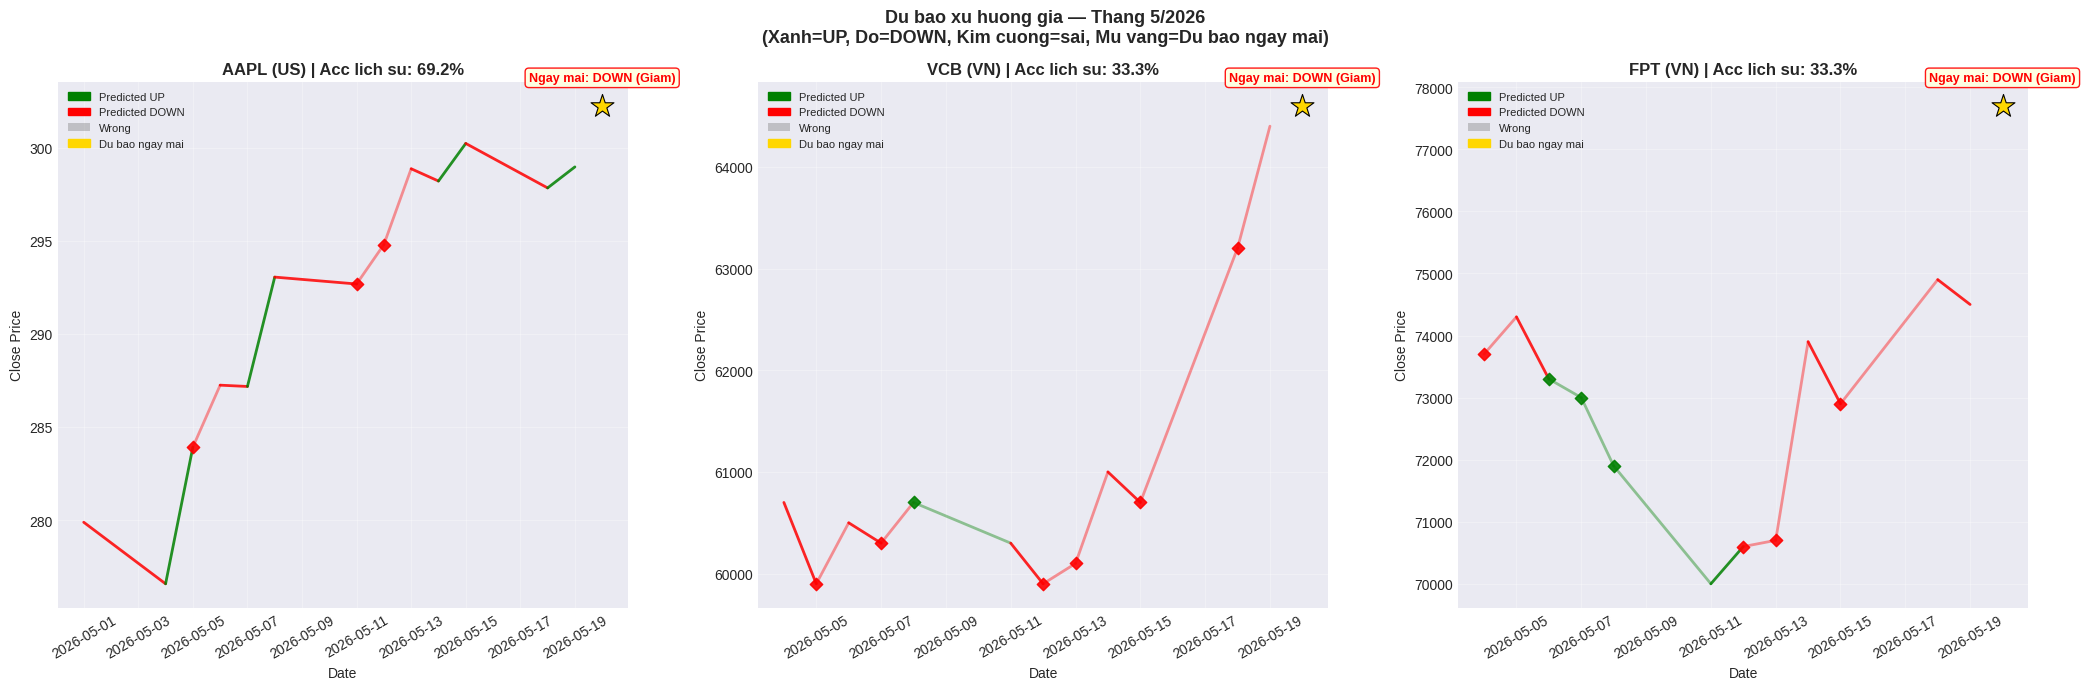


DU BAO XU HUONG — 22/05/2026 (ngay giao dich tiep theo)
  AAPL   (US ) | ▼ DOWN | Close hom nay: 302.25
  VCB    (VN ) | ▼ DOWN | Close hom nay: 64,600.00
  FPT    (VN ) | ▼ DOWN | Close hom nay: 77,700.00
* Du bao dua tren mo hinh train den 2021. Khong phai tu van dau tu.


In [33]:
# ── Ve bieu do gia + du bao ngay mai ────────────────────────────────────────
import matplotlib.patches as mpatches
from datetime import date, timedelta
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f'Du bao xu huong gia — Thang {date.today().month}/{date.today().year}\n'
             '(Xanh=UP, Do=DOWN, Kim cuong=sai, Mu vang=Du bao ngay mai)',
             fontsize=13, fontweight='bold')

tickers      = ['AAPL', 'VCB', 'FPT']
group_labels = ['US',   'VN',  'VN']
next_day_preds = {}

for ax, sym, grp in zip(axes, tickers, group_labels):
    df_full = demo_results[sym].copy().reset_index(drop=True)
    df_full['time'] = pd.to_datetime(df_full['time'])
    df_plot = df_full[df_full['time'] >= pd.Timestamp(DEMO_START)].reset_index(drop=True)

    if len(df_plot) < 2:
        ax.set_title(f'{sym}: khong du du lieu')
        continue

    # ── Phan qua khu: co actual de so sanh ───────────────────────────────
    df_hist = df_plot.copy()
    df_hist['next_close'] = df_hist['close'].shift(-1)
    df_hist['actual_dir'] = (df_hist['next_close'] > df_hist['close']).astype('Int64')
    df_known = df_hist.dropna(subset=['next_close']).copy()

    correct = df_known['prediction'] == df_known['actual_dir']
    acc = correct.mean() * 100 if len(correct) > 0 else 0

    for i in range(len(df_known) - 1):
        row   = df_known.iloc[i]
        color = 'green' if row['prediction'] == 1 else 'red'
        alpha = 0.85 if correct.iloc[i] else 0.4
        ax.plot([df_known['time'].iloc[i], df_known['time'].iloc[i+1]],
                [row['close'], df_known['close'].iloc[i+1]],
                color=color, linewidth=2, alpha=alpha)
        if not correct.iloc[i]:
            ax.scatter(row['time'], row['close'], marker='D', s=40,
                       color=color, zorder=5, alpha=0.9)

    # ── Du bao ngay mai: row cuoi cung ───────────────────────────────────
    last_row  = df_plot.iloc[-1]
    pred_dir  = int(last_row['prediction'])
    pred_color= 'green' if pred_dir == 1 else 'red'
    pred_label= 'UP (Tang)' if pred_dir == 1 else 'DOWN (Giam)'
    next_day_preds[sym] = pred_dir

    # Ve dau * lon tren ngay hom nay
    ax.scatter(last_row['time'], last_row['close'],
               marker='*', s=300, color='gold', zorder=10,
               edgecolors='black', linewidth=0.8)

    # Annotation box
    ax.annotate(f'Ngay mai: {pred_label}',
                xy=(last_row['time'], last_row['close']),
                xytext=(0, 18), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold',
                color=pred_color,
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow',
                          ec=pred_color, alpha=0.9))

    ax.set_title(f'{sym} ({grp}) | Acc lich su: {acc:.1f}%',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

    up_patch   = mpatches.Patch(color='green', label='Predicted UP')
    down_patch = mpatches.Patch(color='red',   label='Predicted DOWN')
    err_patch  = mpatches.Patch(facecolor='gray', alpha=0.4, label='Wrong')
    star_patch = mpatches.Patch(color='gold', label='Du bao ngay mai')
    ax.legend(handles=[up_patch, down_patch, err_patch, star_patch],
              fontsize=8, loc='best')

plt.tight_layout()
plt.show()

# ── Bang tom tat du bao ngay mai ─────────────────────────────────────────────
from datetime import date, timedelta
import numpy as np

tomorrow = date.today() + timedelta(days=1)
# Neu ngay mai la thu 7 hoac CN thi lay thu 2
while tomorrow.weekday() >= 5:
    tomorrow += timedelta(days=1)

print('\n' + '='*60)
print(f'DU BAO XU HUONG — {tomorrow.strftime("%d/%m/%Y")} (ngay giao dich tiep theo)')
print('='*60)
for sym, grp in zip(tickers, group_labels):
    pred  = next_day_preds.get(sym, -1)
    arrow = '  UP' if pred == 1 else 'DOWN'
    icon  = '▲' if pred == 1 else '▼'
    df_f  = demo_results[sym]
    last_close = df_f['close'].iloc[-1]
    print(f'  {sym:<6} ({grp:<3}) | {icon} {arrow} | Close hom nay: {last_close:,.2f}')

print('='*60)
print('* Du bao dua tren mo hinh train den 2021. Khong phai tu van dau tu.')


## PHẦN CUỐI: TỔNG HỢP TẤT CẢ CẢI TIẾN

### 13 cải tiến đã thực hiện:

| # | Cải tiến | Mô tả |
|---|----------|-------|
| 1 | **Tăng ngưỡng label** | `0.2%` → `1.0%` – loại bỏ vùng nhiễu quanh 0 |
| 2 | **Features nhóm 1** | MA20/50, price_vs_ma, Stoch%K, ATR14, OBV signal |
| 3 | **Features nhóm 2** | RSI 7/14, Volatility 5/20d, Momentum 5/10d, BB bandwidth, BB %B, ATR ratio, Volume MA ratio |
| 4 | **Features nhóm 3** | Williams %R, CCI(14), ADX(14), lag5/10_return – **34 features tổng (PySpark)** |
| 5 | **StandardScaler** | Chuẩn hóa features → Logistic Regression hội tụ tốt hơn |
| 6 | **Log-transform Volume** | Giảm skew phân phối, ổn định thang đo |
| 7 | **Class Weighting** | Cân bằng imbalance nhãn 0/1 cho LR, RF, GBT |
| 8 | **LinearSVC** | Model thứ 4 – tối ưu margin thay vì likelihood |
| 9 | **Ensemble Weighted Vote** | LR+RF+GBT+SVC, trọng số theo accuracy |
| 10 | **Walk-forward Validation** | 5-fold rolling window (2019–2023) – đánh giá độ ổn định theo thời gian |
| 11 | **MACD – EMA thực** | Fix SMA proxy → `ewm(span=12)` trong pipeline học sâu |
| 12 | **XGBoost** | Gradient Boosting chuẩn công nghiệp (sklearn/XGBoost) |
| 13 | **LSTM + GRU (Học sâu)** | 2-layer LSTM và GRU với EarlyStopping, ReduceLROnPlateau |

### Pipeline tổng thể:
```
Dữ liệu thô (28 mã, ~10 năm)
  ↓ PySpark Feature Engineering (34 features)
  ↓ StandardScaler + Class Weighting + Time-series Split
  ├─ ML Models: LR / RF / GBT / LinearSVC → Ensemble Weighted Vote
  ├─ Walk-forward Validation (5 folds, 2019–2023)
  └─ Pandas/Keras: XGBoost / LSTM / GRU (EMA MACD thực)
```